# Variational Autoencoder

## 0. Prelim

First, we have a set of $N$ data samples $\mathcal X=\{x_i|i\in \mathbb Z_N \}$, assumed uniquely sampled from an unknown distribution $x_i\sim p_{\text{data}}$.

The MNIST dataset is a good example. In this case, $x_i\in\mathbb R^{784}$.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_data = datasets.MNIST('../0.Data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../0.Data/', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Loaded {len(train_data)} train, {len(test_data)} test samples")

Loaded 60000 train, 10000 test samples


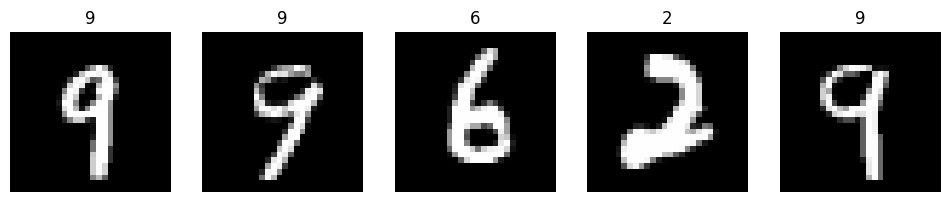

Batch shape: torch.Size([128, 784])
Single image shape: torch.Size([784])


In [4]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].view(28, 28)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')
plt.show()

print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")

## 1. Modelling

Sampling new data points from $p_{\text{data}}$ is impossible, so we aim to make an appoximator parameterized with $p_\phi$.$\\$
A Standard VAE models this through encoders and decoders as below.
$$\text{Data point }x\in\mathbb R^D,\quad\text{Latent vector } z\in\mathbb R^d\quad(D>>d)$$
$$x\sim p_{\text{data}},\quad z\sim q_\theta(z|x),\quad x'\sim p_\phi(x|z)\\$$
At inference, a latent vector $z$ is sampled from a prior distribution $p_{\text{prior}}:=\mathcal N(0,\mathbf I)$ and a data point is sampled from $p_\phi(x|z)$.

Now, if we are to train this architecture to approximate $p_{\text{data}}$ as we first intended, a KL Divergence would be a common choice.
$$\mathcal D_{\text{KL}}(p_{\text{data}}|p_\phi)=\mathbb E_{x\sim p_{\text{data}}}[\log{p_{\text{data}}(x)} - \log{p_{\phi}(x)}]$$
Here we can observe that the computation of $p_\phi(x)$ is inevitable. But, such term is intractable, due to the integral form through the latent space.
$$p_\phi(x)=\int p(x|z)p_{\text{prior}}(z)dz$$
To tackle such problem, the VAE architecture leverages the encoding layer.

By Baye's rule, the posterior distribution is given as below.
$$p_\phi(z|x)=\frac{p_\phi(x|z)p_{\text{prior}}(z)}{p_\phi(x)}=\frac{p_\phi(x|z)p_{\text{prior}}(z)}{\int p(x|z)p_{\text{prior}}(z)dz}$$
This term is stil also intractable, due to the marginal likelihood $p_\phi(x)$. However, we can approximate the encoder to the posterior distribution as below.
$$q_\theta(z|x)\approx p_\phi(z|x)$$

Now with the posterior approximator, we can introduce a lower bound error term for the intractable MLE.
$$\log{p_\phi(x)}\geq\mathcal L_{\text{ELBO}}(\theta,\phi;x)$$
$$\mathcal L_{\text{ELBO}}(\theta,\phi;x)=\mathbb E_{z\sim q_\theta(z|x)}[\log{p_\phi(x|z)}]-\mathcal D_{\text{KL}}(q_\theta(z|x)|p_{\text{prior}}(z))$$
The inequality can be easily proven.
$$\mathcal L_{\text{ELBO}}=\mathbb E_{z\sim q_\theta{z|x}}\log[\frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}]=\int q_\theta(z|x) \log\frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}dz\leq\log\int q_\theta(z|x) \frac{p_\phi(x|z)p_{\text{prior}}(z)}{q_\theta(z|x)}dz=\log p_\phi(x)$$

In practice, such loss would be calculated as a reconstruction loss term from data set $\mathcal X$ and a latent regularization term.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

A Standard implementation of VAEs are the Gaussian VAEs to ensure pdf conditions (normalization & non-negativity)
$$q_\theta(z|x):=\mathcal N(z;\mu_\theta(x),\text{diag}(\sigma^2_\theta(x)))$$
$$$$

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=20, hidden_dim=400):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # Mean
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # Log-variance
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar